In [46]:
import sys
sys.path.append(r'/Users/gabriellebouvier/SIR_Model/src/Particles')

In [47]:
import particles

from sir_PMCMC import ChainBinomialModel
from sir_PMCMC import ScalarStructDist
from sir_PMCMC import custom_mom
import multiprocess as mp
import numpy as np
import pandas as pd
import seaborn as sb
import time
import pickle
import statistics

from particles import distributions as dists
from particles import state_space_models as ssm
from particles.collectors import Moments
from particles import mcmc
from collections import OrderedDict
from particles import collectors as col
from matplotlib import pyplot as plt
from SIR_Model import model, x, y, simulation_df

from statsmodels.graphics.tsaplots import plot_acf


In [48]:
# Open PMCMC files
pmmh_path = f'/Users/gabriellebouvier/SIR_Model/pmmh_tuning_2.pkl'
with open(pmmh_path, 'rb') as output_multi:
    pmmh_tuning = pickle.load(output_multi)

In [49]:
pmmh_list = []
for i in pmmh_tuning:
    pmmh_list.append(i.chain.theta)

In [50]:
np.savez(f"pmmh_tuning.npz", arr0 = pmmh_list)

In [51]:
# List and average cpu time
pmmh_cpu = []
for i in pmmh_tuning:
    pmmh_cpu.append(i.cpu_time)

print(f"The average cpu time when for 1000 iterations was {np.mean(pmmh_cpu):.2f} seconds.")
print(pmmh_cpu)

The average cpu time when for 1000 iterations was 140.82 seconds.
[139.59698283299804, 140.9435604159953, 141.23356920899823, 141.4967428749951]


In [52]:
# List and average acceptance rate
pmmh_acc = []
for i in pmmh_tuning:
    pmmh_acc.append(i.acc_rate)

print(f"The average acceptance rate for 1000 iterations was {np.mean(pmmh_acc):.2f}.")

The average acceptance rate for 1000 iterations was 0.36.


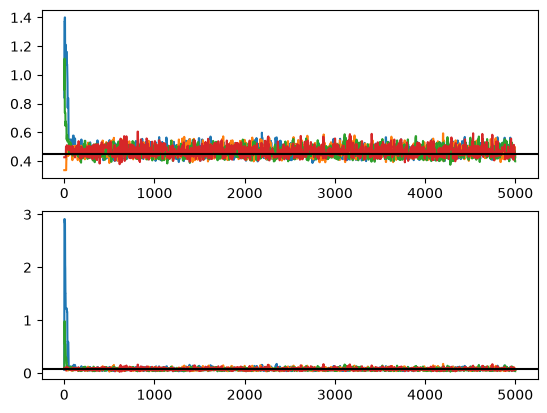

In [53]:
fig, axes = plt.subplots(2,1)
for i in range(4):
    axes[0].plot(pmmh_tuning[i].chain.theta['beta'])

for i in range(4):
    axes[1].plot(pmmh_tuning[i].chain.theta['gamma'])

axes[0].axhline(y = 0.45, color='black')
axes[1].axhline(y = 0.08, color='black')


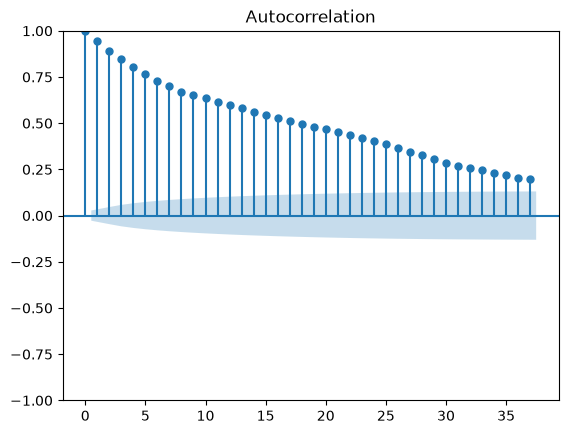

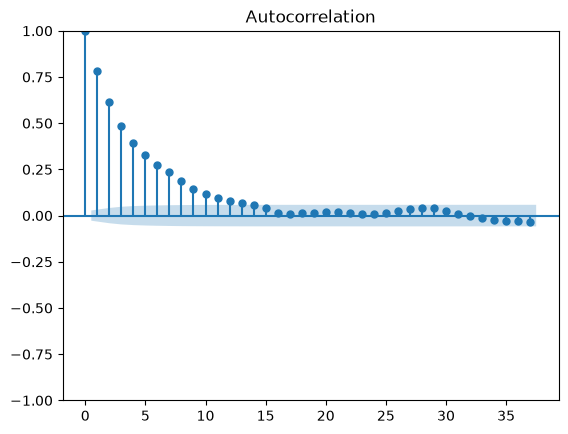

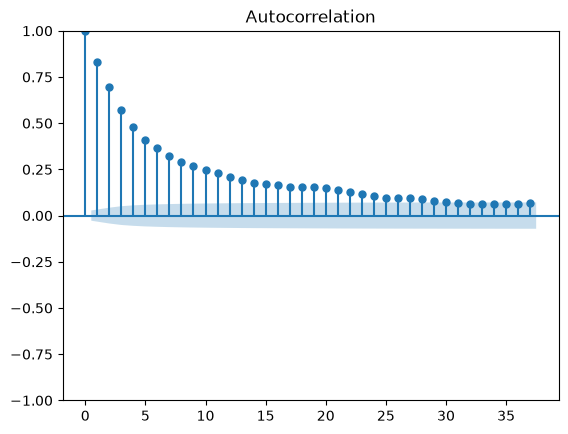

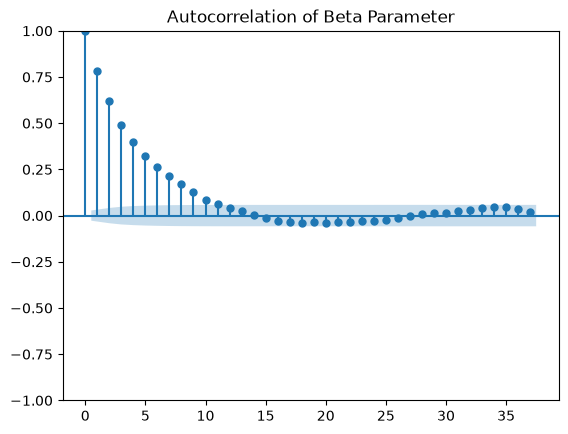

In [55]:
for i in range(4):
    plot_acf(pmmh_tuning[i].chain.theta['beta'])
plt.title('Autocorrelation of Beta Parameter')
plt.show()